# Multi-Task Property Prediction &mdash; Attention + 1D-CNN

Predicts **solubility (LogS)**, **BBB permeability**, and **toxicity** from a SMILES string.

This version treats the 12 molecular descriptors as a short 1D signal. Two `Conv1d` layers
slide over it to learn local interactions between neighbouring descriptors, and instead of
average/max pooling, an **additive (Bahdanau-style) attention layer** learns a softmax weight
per position and takes a weighted sum &mdash; the network decides which descriptors to focus on,
per molecule, rather than treating every position equally.

Trained on the same ~16,400-molecule merged dataset (AqSolDB + BBBP + Tox21) and the same
masked multi-task loss as the companion Attention-MLP notebook, so the two are directly
comparable.


## 1. Setup

In [1]:
# If a package is missing, uncomment and run:
# %pip install rdkit scikit-learn torch pandas numpy matplotlib joblib

import os
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")   # silence RDKit's SMILES parsing warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, roc_auc_score

import joblib

os.makedirs("../data", exist_ok=True)
os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


## 2. Download the raw datasets

Three public datasets, fetched from GitHub mirrors. Skipped if already present in `../data`
(e.g. if you've included `multitask_merged.csv` already, everything below reuses it directly).


In [2]:
DATA_URLS = {
    "aqsoldb_raw.csv": "https://raw.githubusercontent.com/mcsorkun/AqSolDB/master/results/data_curated.csv",
    "bbbp_raw.csv":    "https://raw.githubusercontent.com/dasdibye/bbbpDL/master/BBBP.csv",
    "tox21_raw.csv.gz":"https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/tox21.csv.gz",
}

for fname, url in DATA_URLS.items():
    path = os.path.join("../data", fname)
    if not os.path.exists(path):
        print("Downloading", fname, "...")
        urllib.request.urlretrieve(url, path)
    else:
        print(fname, "already present, skipping download")

import gzip, shutil
tox_gz = "../data/tox21_raw.csv.gz"
tox_csv = "../data/tox21_raw.csv"
if os.path.exists(tox_gz) and not os.path.exists(tox_csv):
    with gzip.open(tox_gz, "rb") as f_in, open(tox_csv, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Done.")


aqsoldb_raw.csv already present, skipping download
bbbp_raw.csv already present, skipping download
tox21_raw.csv.gz already present, skipping download
Done.


## 3. Molecular descriptors + merged multi-task table

Computes 12 RDKit descriptors per molecule and merges AqSolDB (solubility), BBBP (BBB
permeability), and Tox21 (aggregated toxicity flag) into one sparse multi-task table on
canonical SMILES. Skips straight to `multitask_merged.csv` if it already exists.


In [3]:
FEATURES = [
    "Molecular_Weight", "LogP", "TPSA", "H_Bond_Donors", "H_Bond_Acceptors",
    "Rotatable_Bonds", "Ring_Count", "Heavy_Atom_Count", "Fraction_CSP3",
    "Aromatic_Rings", "Molar_Refractivity", "Num_Heteroatoms",
    "Num_Aromatic_Carbocycles", "BalabanJ", "Labute_ASA",
]

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "canonical_smiles": Chem.MolToSmiles(mol),
        "Molecular_Weight": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "H_Bond_Donors": Lipinski.NumHDonors(mol),
        "H_Bond_Acceptors": Lipinski.NumHAcceptors(mol),
        "Rotatable_Bonds": Lipinski.NumRotatableBonds(mol),
        "Ring_Count": Lipinski.RingCount(mol),
        "Heavy_Atom_Count": Lipinski.HeavyAtomCount(mol),
        "Fraction_CSP3": Lipinski.FractionCSP3(mol),
        "Aromatic_Rings": Lipinski.NumAromaticRings(mol),
        "Molar_Refractivity": Crippen.MolMR(mol),
        "Num_Heteroatoms": Lipinski.NumHeteroatoms(mol),
        "Num_Aromatic_Carbocycles": Lipinski.NumAromaticCarbocycles(mol),
        "BalabanJ": Descriptors.BalabanJ(mol),
        "Labute_ASA": Descriptors.LabuteASA(mol),
    }

MERGED_PATH = "../data/multitask_merged.csv"

if os.path.exists(MERGED_PATH):
    print("Found existing merged dataset, loading it directly.")
    merged = pd.read_csv(MERGED_PATH)

else:
    print("Building merged dataset from the three raw sources...")

    aq = pd.read_csv("../data/aqsoldb_raw.csv")
    rows = []
    for smi, sol in zip(aq["SMILES"], aq["Solubility"]):
        d = calc_descriptors(smi)
        if d is None:
            continue
        d["LogS"] = sol
        rows.append(d)
    aq_feat = pd.DataFrame(rows).drop_duplicates(subset="canonical_smiles")
    print("AqSolDB usable:", aq_feat.shape)

    bbbp = pd.read_csv("../data/bbbp_raw.csv")
    rows = []
    for smi, label in zip(bbbp["smiles"], bbbp["p_np"]):
        d = calc_descriptors(smi)
        if d is None:
            continue
        d["BBB"] = label
        rows.append(d)
    bbbp_feat = pd.DataFrame(rows).drop_duplicates(subset="canonical_smiles")
    print("BBBP usable:", bbbp_feat.shape)

    tox = pd.read_csv("../data/tox21_raw.csv")
    assay_cols = [c for c in tox.columns if c not in ("mol_id", "smiles")]

    def aggregate_toxicity(row):
        vals = row[assay_cols].dropna()
        if len(vals) == 0:
            return np.nan
        return 1.0 if vals.max() >= 1 else 0.0

    tox["Toxic"] = tox.apply(aggregate_toxicity, axis=1)
    tox = tox.dropna(subset=["Toxic"])
    rows = []
    for smi, label in zip(tox["smiles"], tox["Toxic"]):
        d = calc_descriptors(smi)
        if d is None:
            continue
        d["Toxic"] = label
        rows.append(d)
    tox_feat = pd.DataFrame(rows).drop_duplicates(subset="canonical_smiles")
    print("Tox21 usable:", tox_feat.shape)

    aq_m = aq_feat[["canonical_smiles"] + FEATURES + ["LogS"]]
    bbbp_m = bbbp_feat[["canonical_smiles", "BBB"]]
    tox_m = tox_feat[["canonical_smiles", "Toxic"]]

    merged = aq_m.merge(bbbp_m, on="canonical_smiles", how="outer")
    merged = merged.merge(tox_m, on="canonical_smiles", how="outer")

    lookup = (
        pd.concat([aq_feat, bbbp_feat, tox_feat])
        .drop_duplicates(subset="canonical_smiles")
        .set_index("canonical_smiles")
    )
    missing = merged[FEATURES[0]].isna()
    for idx in merged.index[missing]:
        smi = merged.loc[idx, "canonical_smiles"]
        if smi in lookup.index:
            merged.loc[idx, FEATURES] = lookup.loc[smi, FEATURES]

    merged = merged.dropna(subset=FEATURES)
    merged.to_csv(MERGED_PATH, index=False)

print("\nFinal dataset:", merged.shape)
print(merged[["LogS", "BBB", "Toxic"]].notna().sum())


Found existing merged dataset, loading it directly.

Final dataset: (16436, 19)
LogS     9980
BBB      1975
Toxic    7823
dtype: int64


In [4]:
# Add 3 new descriptors to the already-merged dataset without re-downloading/re-merging anything
from rdkit.Chem import Lipinski

def add_new_descriptors(row):
    mol = Chem.MolFromSmiles(row["canonical_smiles"])
    return pd.Series({
        "Num_Aromatic_Carbocycles": Lipinski.NumAromaticCarbocycles(mol),
        "BalabanJ": Descriptors.BalabanJ(mol),
        "Labute_ASA": Descriptors.LabuteASA(mol),
    })

merged[["Num_Aromatic_Carbocycles", "BalabanJ", "Labute_ASA"]] = merged.apply(add_new_descriptors, axis=1)
merged.to_csv("../data/multitask_merged.csv", index=False)
print("Patched. New shape:", merged.shape)
merged.head()

Patched. New shape: (16436, 19)


,canonical_smiles,Molecular_Weight,LogP,TPSA,H_Bond_Donors,H_Bond_Acceptors,Rotatable_Bonds,Ring_Count,Heavy_Atom_Count,Fraction_CSP3,Aromatic_Rings,Molar_Refractivity,Num_Heteroatoms,LogS,BBB,Toxic,Num_Aromatic_Carbocycles,BalabanJ,Labute_ASA
0,B#N,24.819,-0.36572,23.79,0.0,1.0,0.0,0.0,2.0,0.0,0.0,7.479,2.0,-6.394784,NaN,NaN,0.0,3.000000,13.910622
1,B12B3B4B1C234,55.259,-1.30840,0.00,0.0,0.0,0.0,4.0,5.0,1.0,0.0,25.709,4.0,-4.742403,NaN,NaN,0.0,2.711084,31.938631
2,Br/C=C/Br,185.846,2.24740,0.00,0.0,0.0,0.0,0.0,4.0,0.0,0.0,26.994,2.0,-1.741500,NaN,NaN,0.0,2.549193,42.149685
3,Br/C=C\Br,185.846,2.24740,0.00,0.0,0.0,0.0,0.0,4.0,0.0,0.0,26.994,2.0,-1.319500,NaN,NaN,0.0,2.549193,42.149685
4,BrC(Br)(Br)Br,331.627,3.17730,0.00,0.0,0.0,0.0,0.0,5.0,1.0,0.0,38.439,4.0,-3.140400,NaN,NaN,0.0,3.023716,64.209441


## 4. Train / validation / test split

In [5]:
train_df, test_df = train_test_split(merged, test_size=0.15, random_state=SEED)
train_df, val_df  = train_test_split(train_df, test_size=0.1765, random_state=SEED)  # -> ~15% of total

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATURES].values)
X_val   = scaler.transform(val_df[FEATURES].values)
X_test  = scaler.transform(test_df[FEATURES].values)

def make_targets(d):
    def col(name):
        vals = d[name].values.astype(np.float32)
        mask = (~d[name].isna()).values.astype(np.float32)
        return np.nan_to_num(vals, nan=0.0), mask
    logs, logs_mask = col("LogS")
    bbb, bbb_mask   = col("BBB")
    tox, tox_mask   = col("Toxic")
    return logs, logs_mask, bbb, bbb_mask, tox, tox_mask

def to_tensors(X, d):
    logs, logs_m, bbb, bbb_m, tox, tox_m = make_targets(d)
    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(logs), torch.tensor(logs_m),
        torch.tensor(bbb), torch.tensor(bbb_m),
        torch.tensor(tox), torch.tensor(tox_m),
    )

Xtr, logs_tr, logsm_tr, bbb_tr, bbbm_tr, tox_tr, toxm_tr = to_tensors(X_train, train_df)
Xva, logs_va, logsm_va, bbb_va, bbbm_va, tox_va, toxm_va = to_tensors(X_val, val_df)
Xte, logs_te, logsm_te, bbb_te, bbbm_te, tox_te, toxm_te = to_tensors(X_test, test_df)

def masked_loss(pred, target, mask, lossfn):
    l = lossfn(pred, target) * mask
    denom = mask.sum().clamp(min=1.0)
    return l.sum() / denom

mse = nn.MSELoss(reduction="none")
bce = nn.BCEWithLogitsLoss(reduction="none")


Train: 11504  Val: 2466  Test: 2466


## 5. Model &mdash; Attention + 1D-CNN

`Conv1d` layers extract local patterns across neighbouring descriptors; an attention-scoring
head (`Linear -> Tanh -> Linear -> softmax`) then pools the convolved sequence into a single
vector, weighting each position by how relevant it is for that molecule.


In [6]:
class AttentionCNN(nn.Module):
    def __init__(self, n_features, conv_channels=(32, 64), kernel_size=3, mlp_hidden=64, dropout=0.1):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(1, conv_channels[0], kernel_size, padding=pad)
        self.bn1 = nn.BatchNorm1d(conv_channels[0])
        self.conv2 = nn.Conv1d(conv_channels[0], conv_channels[1], kernel_size, padding=pad)
        self.bn2 = nn.BatchNorm1d(conv_channels[1])
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        # Additive attention: score each conv position, softmax over positions
        self.attn_score = nn.Sequential(
            nn.Linear(conv_channels[1], conv_channels[1] // 2),
            nn.Tanh(),
            nn.Linear(conv_channels[1] // 2, 1),
        )

        self.trunk = nn.Sequential(
            nn.Linear(conv_channels[1], mlp_hidden), nn.ReLU(),
            nn.BatchNorm1d(mlp_hidden), nn.Dropout(dropout),
        )
        self.solubility_head = nn.Linear(mlp_hidden, 1)
        self.bbb_head = nn.Linear(mlp_hidden, 1)
        self.tox_head = nn.Linear(mlp_hidden, 1)

    def forward(self, x, return_attn=False):
        h = x.unsqueeze(1)                        # (B, 1, F) -- 1 input channel
        h = self.relu(self.bn1(self.conv1(h)))
        h = self.dropout(h)
        h = self.relu(self.bn2(self.conv2(h)))    # (B, C, F)
        h = h.transpose(1, 2)                     # (B, F, C)

        scores = self.attn_score(h).squeeze(-1)               # (B, F)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (B, F, 1)
        pooled = (h * weights).sum(dim=1)                     # (B, C) attention-weighted pooling

        z = self.trunk(pooled)
        out = (
            self.solubility_head(z).squeeze(-1),
            self.bbb_head(z).squeeze(-1),
            self.tox_head(z).squeeze(-1),
        )
        return (out, weights.squeeze(-1)) if return_attn else out


## 6. Train

In [7]:
def train_model(model, n_epochs=80, batch_size=256, lr=1e-3, log_every=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    n = Xtr.shape[0]
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(n)
        total_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            optimizer.zero_grad()
            p_logs, p_bbb, p_tox = model(Xtr[idx])
            loss = (masked_loss(p_logs, logs_tr[idx], logsm_tr[idx], mse)
                    + masked_loss(p_bbb, bbb_tr[idx], bbbm_tr[idx], bce)
                    + masked_loss(p_tox, tox_tr[idx], toxm_tr[idx], bce))
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(idx)

        model.eval()
        with torch.no_grad():
            p_logs, p_bbb, p_tox = model(Xva)
            vloss = (masked_loss(p_logs, logs_va, logsm_va, mse)
                     + masked_loss(p_bbb, bbb_va, bbbm_va, bce)
                     + masked_loss(p_tox, tox_va, toxm_va, bce)).item()
        history["train_loss"].append(total_loss / n)
        history["val_loss"].append(vloss)
        if (epoch + 1) % log_every == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d} | train_loss={total_loss/n:.4f} | val_loss={vloss:.4f}")

    return history

model = AttentionCNN(n_features=len(FEATURES))
n_params = sum(p.numel() for p in model.parameters())
print(f"Attention + 1D-CNN parameters: {n_params:,}")

import time
t0 = time.time()
history = train_model(model, n_epochs=80)
train_time = time.time() - t0
print(f"\nTraining took {train_time:.1f}s")


Attention + 1D-CNN parameters: 13,124
Epoch   1 | train_loss=12.6068 | val_loss=10.6269
Epoch  10 | train_loss=2.8628 | val_loss=2.7783
Epoch  20 | train_loss=2.6203 | val_loss=2.4847
Epoch  30 | train_loss=2.5627 | val_loss=2.4645
Epoch  40 | train_loss=2.5285 | val_loss=2.4708
Epoch  50 | train_loss=2.4028 | val_loss=2.4740
Epoch  60 | train_loss=2.3706 | val_loss=2.5067
Epoch  70 | train_loss=2.3836 | val_loss=2.4186
Epoch  80 | train_loss=2.3468 | val_loss=2.4431

Training took 92.4s


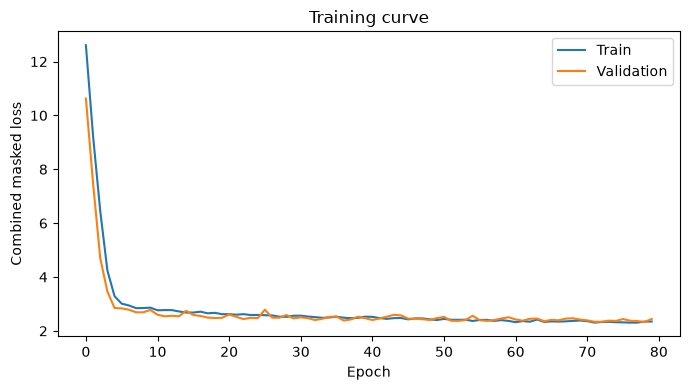

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["train_loss"], label="Train")
ax.plot(history["val_loss"], label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Combined masked loss")
ax.set_title("Training curve")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Test-set evaluation

In [9]:
model.eval()
with torch.no_grad():
    p_logs, p_bbb, p_tox = model(Xte)

m = logsm_te.numpy().astype(bool)
y_true, y_pred = logs_te.numpy()[m], p_logs.numpy()[m]
sol = dict(n=int(m.sum()), MAE=mean_absolute_error(y_true, y_pred),
           RMSE=mean_squared_error(y_true, y_pred) ** 0.5, R2=r2_score(y_true, y_pred))
print(f"Solubility (n={sol['n']}): MAE={sol['MAE']:.4f}  RMSE={sol['RMSE']:.4f}  R2={sol['R2']:.4f}")

m = bbbm_te.numpy().astype(bool)
probs = torch.sigmoid(p_bbb).numpy()[m]
preds = (probs >= 0.5).astype(int)
y_true = bbb_te.numpy()[m]
bbb = dict(n=int(m.sum()), Accuracy=accuracy_score(y_true, preds), ROC_AUC=roc_auc_score(y_true, probs))
print(f"BBB        (n={bbb['n']}): Accuracy={bbb['Accuracy']:.4f}  ROC-AUC={bbb['ROC_AUC']:.4f}")

m = toxm_te.numpy().astype(bool)
probs = torch.sigmoid(p_tox).numpy()[m]
preds = (probs >= 0.5).astype(int)
y_true = tox_te.numpy()[m]
tox = dict(n=int(m.sum()), Accuracy=accuracy_score(y_true, preds), ROC_AUC=roc_auc_score(y_true, probs))
print(f"Toxicity   (n={tox['n']}): Accuracy={tox['Accuracy']:.4f}  ROC-AUC={tox['ROC_AUC']:.4f}")


Solubility (n=1484): MAE=0.9218  RMSE=1.2752  R2=0.7209
BBB        (n=296): Accuracy=0.8750  ROC-AUC=0.8767
Toxicity   (n=1171): Accuracy=0.7122  ROC-AUC=0.7491


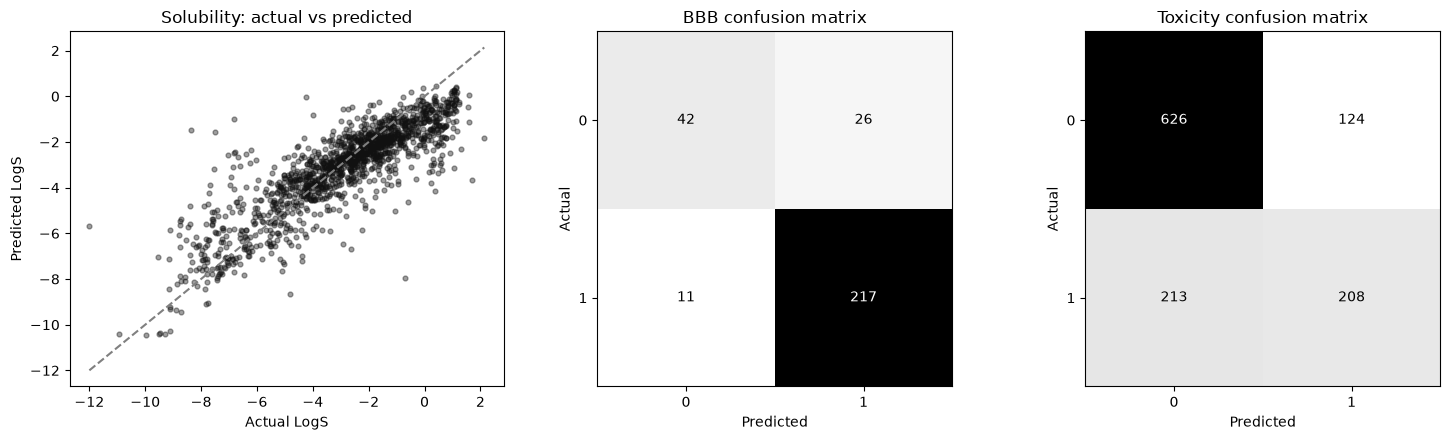

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

m = logsm_te.numpy().astype(bool)
axes[0].scatter(logs_te.numpy()[m], p_logs.numpy()[m], alpha=0.4, s=12, color="#111111")
lims = [min(logs_te.numpy()[m].min(), p_logs.numpy()[m].min()),
        max(logs_te.numpy()[m].max(), p_logs.numpy()[m].max())]
axes[0].plot(lims, lims, "--", color="gray")
axes[0].set_title("Solubility: actual vs predicted")
axes[0].set_xlabel("Actual LogS"); axes[0].set_ylabel("Predicted LogS")

from sklearn.metrics import confusion_matrix
for ax, name, y_true, probs_full, mask in [
    (axes[1], "BBB", bbb_te.numpy(), torch.sigmoid(p_bbb).numpy(), bbbm_te.numpy().astype(bool)),
    (axes[2], "Toxicity", tox_te.numpy(), torch.sigmoid(p_tox).numpy(), toxm_te.numpy().astype(bool)),
]:
    yt = y_true[mask]
    yp = (probs_full[mask] >= 0.5).astype(int)
    cm = confusion_matrix(yt, yp)
    ax.imshow(cm, cmap="Greys")
    ax.set_title(f"{name} confusion matrix")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center", color="white" if v > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 8. Save model + metrics

In [11]:
torch.save(model.state_dict(), "../models/attention_cnn_model.pt")
joblib.dump(scaler, "../models/attention_cnn_scaler.pkl")

results = dict(
    architecture="Attention + 1D-CNN",
    n_params=n_params,
    train_time_s=round(train_time, 1),
    solubility=sol,
    bbb=bbb,
    toxicity=tox,
    history=history,
)
with open("../results/attention_cnn_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved:")
print(" - models/attention_cnn_model.pt")
print(" - models/attention_cnn_scaler.pkl")
print(" - results/attention_cnn_results.json")


Saved:
 - models/attention_cnn_model.pt
 - models/attention_cnn_scaler.pkl
 - results/attention_cnn_results.json


## 9. What is the attention layer looking at?

Because pooling here *is* an attention layer, we can read off which descriptor positions the
model leaned on most for a given molecule &mdash; built-in interpretability the Attention-MLP
notebook doesn't directly expose in the same way.


In [12]:
sample_idx = np.random.RandomState(0).choice(len(Xte), size=5, replace=False)
model.eval()
with torch.no_grad():
    _, attn_weights = model(Xte[sample_idx], return_attn=True)

attn_df = pd.DataFrame(attn_weights.numpy(), columns=FEATURES,
                        index=[f"molecule_{i}" for i in sample_idx])
attn_df.style.format("{:.3f}").background_gradient(cmap="Greys", axis=1)


,Molecular_Weight,LogP,TPSA,H_Bond_Donors,H_Bond_Acceptors,Rotatable_Bonds,Ring_Count,Heavy_Atom_Count,Fraction_CSP3,Aromatic_Rings,Molar_Refractivity,Num_Heteroatoms,Num_Aromatic_Carbocycles,BalabanJ,Labute_ASA
molecule_575,0.223,0.117,0.074,0.041,0.031,0.048,0.037,0.037,0.050,0.114,0.085,0.024,0.037,0.034,0.047
molecule_1096,0.143,0.053,0.050,0.086,0.085,0.009,0.013,0.034,0.066,0.038,0.036,0.108,0.199,0.027,0.053
molecule_1791,0.299,0.139,0.100,0.050,0.015,0.042,0.058,0.003,0.017,0.047,0.100,0.058,0.010,0.038,0.023
molecule_715,0.167,0.049,0.043,0.068,0.045,0.061,0.044,0.057,0.028,0.048,0.134,0.149,0.062,0.025,0.021
molecule_1023,0.156,0.040,0.018,0.039,0.115,0.106,0.097,0.074,0.065,0.061,0.053,0.048,0.030,0.077,0.022


## 10. Quick sanity check on new molecules

In [13]:
def predict_one(smiles):
    d = calc_descriptors(smiles)
    if d is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    x = np.array([[d[f] for f in FEATURES]])
    x = scaler.transform(x)
    x = torch.tensor(x, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        p_logs, p_bbb, p_tox = model(x)

    return {
        "smiles": smiles,
        "predicted_logS": round(float(p_logs.item()), 3),
        "bbb_permeant_prob": round(float(torch.sigmoid(p_bbb).item()), 3),
        "toxic_prob": round(float(torch.sigmoid(p_tox).item()), 3),
    }

for smi in ["CCO", "c1ccccc1", "CC(=O)Oc1ccccc1C(=O)O", "CN1CCC[C@H]1c1cccnc1"]:
    print(predict_one(smi))


{'smiles': 'CCO', 'predicted_logS': -0.182, 'bbb_permeant_prob': 0.947, 'toxic_prob': 0.193}
{'smiles': 'c1ccccc1', 'predicted_logS': -2.162, 'bbb_permeant_prob': 0.986, 'toxic_prob': 0.183}
{'smiles': 'CC(=O)Oc1ccccc1C(=O)O', 'predicted_logS': -2.082, 'bbb_permeant_prob': 0.87, 'toxic_prob': 0.41}
{'smiles': 'CN1CCC[C@H]1c1cccnc1', 'predicted_logS': -1.883, 'bbb_permeant_prob': 0.979, 'toxic_prob': 0.222}
